含噪 PSNR: 16.45 dB
H1-Tikhonov PSNR: 21.19 dB
TV PSNR: 26.58 dB


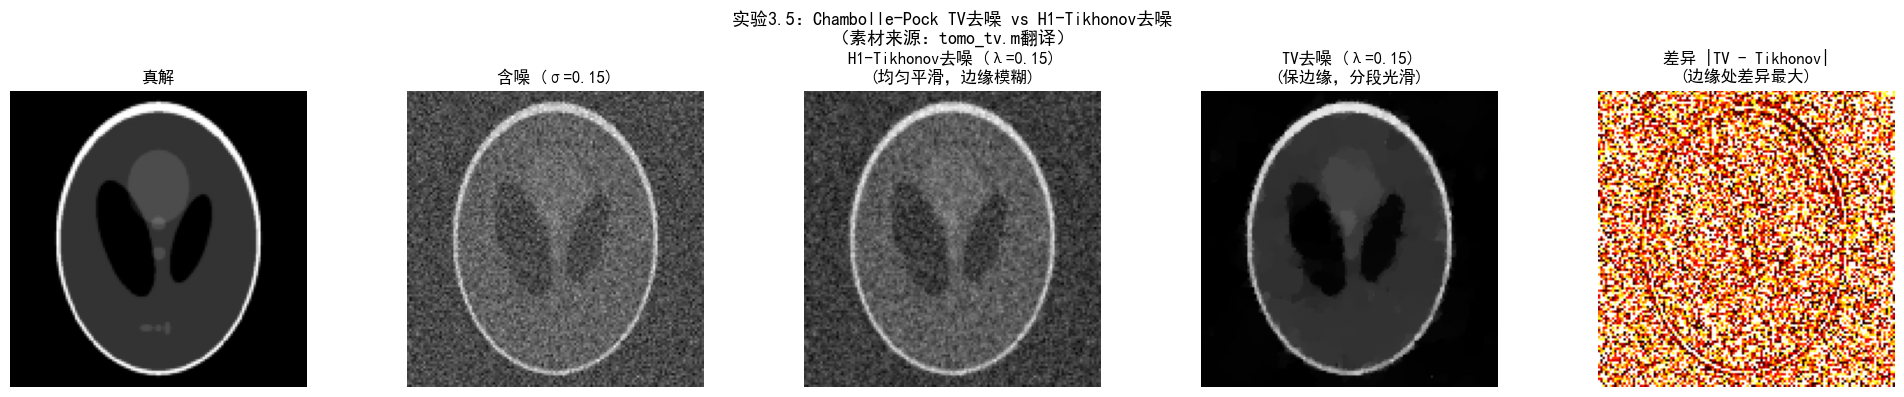

In [2]:
"""
实验3.5 Chambolle-Pock算法TV去噪
对应章节：3.5（TV正则化、ROF模型、Fenchel对偶、Chambolle-Pock算法）
素材来源：winter_school/BolognaWinterSchool2023-main/Matlab/tomo_tv.m (Python翻译，简化为ROF去噪)
          winter_school/BolognaWinterSchool2023-main/Matlab/dxp.m, dyp.m, dxm_ad.m, dym_ad.m (Python翻译)
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

# ---- 1. 有限差分算子（取自dxp.m, dyp.m, dxm_ad.m, dym_ad.m的Python翻译）----

def dxp(u):
    """前向差分(水平): (D_h x)_{i,j} = x_{i,j+1} - x_{i,j}
    翻译自 dxp.m: dx = [u(:,2:end) u(:,end)] - u
    """
    return np.roll(u, -1, axis=1) - u

def dyp(u):
    """前向差分(垂直): (D_v x)_{i,j} = x_{i+1,j} - x_{i,j}
    翻译自 dyp.m: dy = [u(2:end,:); u(end,:)] - u
    """
    return np.roll(u, -1, axis=0) - u

def dxm_ad(p):
    """水平差分的伴随:
    翻译自 dxm_ad.m: dx = [u(:,1:end-1) zeros(M,1)] - [zeros(M,1) u(:,1:end-1)]
    """
    return p - np.roll(p, 1, axis=1)

def dym_ad(p):
    """垂直差分的伴随:
    翻译自 dym_ad.m: dy = [u(1:end-1,:);zeros(1,N)] - [zeros(1,N);u(1:end-1,:)]
    """
    return p - np.roll(p, 1, axis=0)

# ---- 2. Chambolle-Pock算法（取自tomo_tv.m，简化为ROF去噪）----

def chambolle_pock_tv_denoise(y, lam, maxiter=500):
    """
    Chambolle-Pock求解ROF模型: min_x 0.5||x-y||^2 + lambda||Dx||_{2,1}

    翻译自 tomo_tv.m (Kristian Bredies, 2012; modified by Samuli Siltanen)
    原代码用于CT重建 (min 0.5||Ax-m||^2 + lambda||Dx||_1)
    此处简化A=I（去噪），保留算法核心结构

    鞍点形式: min_x max_p <Dx, p> + 0.5||x-y||^2 - iota_{||p||_infty<=lambda}(p)

    核心翻译对应关系:
        tomo_tv.m 第35-36行: sigma = 1/sqrt(L2); tau = 1/sqrt(L2)
        tomo_tv.m 第38-48行: 对偶步 (v和p的上升步)
        tomo_tv.m 第50-56行: 原始步 (u的下降步)
        tomo_tv.m 第58行:   外推步 (u_ = 2*u - uold)
    """
    n1, n2 = y.shape
    x = np.zeros((n1, n2))        # 原始变量
    x_bar = np.zeros((n1, n2))    # 外推点
    px = np.zeros((n1, n2))       # 对偶变量(水平)
    py = np.zeros((n1, n2))       # 对偶变量(垂直)

    # 步长 (取自tomo_tv.m: L2=8, sigma=tau=1/sqrt(L2))
    L2 = 8.0
    sigma = 1.0 / np.sqrt(L2)
    tau = 1.0 / np.sqrt(L2)

    for k in range(maxiter):
        # ---- 对偶步 (翻译自tomo_tv.m第38-48行) ----
        gx = dxp(x_bar)   # 对应 tomo_tv.m: ux = dxp(u_)
        gy = dyp(x_bar)   # 对应 tomo_tv.m: uy = dyp(u_)
        px = px + sigma * gx
        py = py + sigma * gy

        # prox of iota_{||·||_infty<=lambda}: 投影到L∞球
        # (翻译自tomo_tv.m第44-46行: pabsm = max(1, sqrt(px.^2+py.^2)/lambda))
        norm_p = np.sqrt(px**2 + py**2)
        factor = np.maximum(1.0, norm_p / lam)
        px = px / factor
        py = py / factor

        # ---- 原始步 (翻译自tomo_tv.m第50-55行) ----
        x_old = x.copy()
        div_p = dxm_ad(px) + dym_ad(py)  # 对应 tomo_tv.m: div = dxm_ad(px) + dym_ad(py)

        # ROF: prox_{tau*0.5||·-y||^2}(v) = (v + tau*y)/(1+tau)
        # (tomo_tv.m中为 x = x - tau*(adjoint - div)，此处A=I简化)
        x = (x - tau * (-div_p) + tau * y) / (1 + tau)
        x = np.maximum(0, x)  # 非负约束 (对应tomo_tv.m: u = max(0,u))

        # ---- 外推步 (翻译自tomo_tv.m第58行: u_ = 2*u - uold) ----
        x_bar = 2 * x - x_old

    return x

# ---- 3. 运行实验 ----
np.random.seed(42)
n = 128
x_true = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=True)

sigma = 0.15
y = x_true + sigma * np.random.randn(n, n)

# TV去噪
lam_tv = 0.15
x_tv = chambolle_pock_tv_denoise(y, lam_tv, maxiter=500)

# Tikhonov去噪（H1正则化：‖Dx‖₂²，与TV公平对比）
# 正则项为 (λ/2)‖Dx‖₂²（梯度的L2范数），闭式解在Fourier域
lam_tikh = 0.15  # 与TV使用相同λ，便于对比
DxDx_hat = 2 - 2*np.cos(2*np.pi*np.arange(n)/n)  # 1D差分算子的频域特征值
DX, DY = np.meshgrid(DxDx_hat, DxDx_hat)
DtD_hat = DX + DY  # 二维有限差分算子 D^T D 的频域对角化
Y_hat = np.fft.fft2(y)
X_tikh_hat = Y_hat / (1 + lam_tikh * DtD_hat)  # (I + λ D^T D)^{-1} y
x_tikh = np.real(np.fft.ifft2(X_tikh_hat))

# 可视化
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(x_true, cmap='gray')
axes[0].set_title('真解')
axes[1].imshow(y, cmap='gray')
axes[1].set_title(f'含噪 (σ={sigma})')
axes[2].imshow(x_tikh, cmap='gray')
axes[2].set_title(f'H1-Tikhonov去噪 (λ={lam_tikh})\n(均匀平滑，边缘模糊)')
axes[3].imshow(x_tv, cmap='gray')
axes[3].set_title(f'TV去噪 (λ={lam_tv})\n(保边缘，分段光滑)')

# 差异图：TV vs Tikhonov
diff = np.abs(x_tv - x_tikh)
axes[4].imshow(diff, cmap='hot', vmin=0, vmax=0.1)
axes[4].set_title('差异 |TV - Tikhonov|\n(边缘处差异最大)')

for ax in axes:
    ax.axis('off')

psnr_noisy = peak_signal_noise_ratio(x_true, y)
psnr_tikh = peak_signal_noise_ratio(x_true, np.clip(x_tikh, 0, 1))
psnr_tv = peak_signal_noise_ratio(x_true, np.clip(x_tv, 0, 1))
print(f"含噪 PSNR: {psnr_noisy:.2f} dB")
print(f"H1-Tikhonov PSNR: {psnr_tikh:.2f} dB")
print(f"TV PSNR: {psnr_tv:.2f} dB")

plt.suptitle('实验3.5：Chambolle-Pock TV去噪 vs H1-Tikhonov去噪\n（素材来源：tomo_tv.m翻译）', fontsize=13)
plt.tight_layout()
plt.show()
